# Diabetes Progression Model — Training

Baseline regression model on the **scikit-learn toy diabetes dataset** (`sklearn.datasets.load_diabetes`).

**What the model predicts:** the dataset target is a *quantitative measure of disease progression one year
after baseline* (range ~25–346). We train a **Linear Regression** baseline to predict that score, then apply a
threshold to turn the score into a **diabetic / not-diabetic** class label.

Pipeline artefacts are saved to `models/` for the Streamlit app to consume.

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
print("setup ok")

setup ok


## 1. Load the toy dataset

We load it **unscaled** (`scaled=False`) so the features keep their real-world units (age in years, BMI, blood
pressure, serum measurements). That lets the Streamlit UI collect values a human can actually understand —
scaling is handled inside the model pipeline instead.

In [2]:
raw = load_diabetes(scaled=False, as_frame=True)
X = raw.data.copy()
y = raw.target.copy()

FEATURE_LABELS = {
    "age": "Age (years)",
    "sex": "Sex (1 = male, 2 = female)",
    "bmi": "Body mass index",
    "bp":  "Average blood pressure (mm Hg)",
    "s1":  "S1 — Total serum cholesterol (tc)",
    "s2":  "S2 — Low-density lipoproteins (ldl)",
    "s3":  "S3 — High-density lipoproteins (hdl)",
    "s4":  "S4 — Total cholesterol / HDL ratio (tch)",
    "s5":  "S5 — Log of serum triglycerides (ltg)",
    "s6":  "S6 — Blood sugar level (glu)",
}

print(f"samples: {X.shape[0]}   features: {X.shape[1]}")
print(f"target range: {y.min():.0f} - {y.max():.0f}   mean: {y.mean():.1f}")
X.head()

samples: 442   features: 10
target range: 25 - 346   mean: 152.1


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


In [3]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,48.518100,13.109028,19.0000,38.2500,50.00000,59.0000,79.000
sex,442.0,1.468326,0.499561,1.0000,1.0000,1.00000,2.0000,2.000
bmi,442.0,26.375792,4.418122,18.0000,23.2000,25.70000,29.2750,42.200
bp,442.0,94.647014,13.831283,62.0000,84.0000,93.00000,105.0000,133.000
s1,442.0,189.140271,34.608052,97.0000,164.2500,186.00000,209.7500,301.000
s2,442.0,115.439140,30.413081,41.6000,96.0500,113.00000,134.5000,242.400
s3,442.0,49.788462,12.934202,22.0000,40.2500,48.00000,57.7500,99.000
s4,442.0,4.070249,1.290450,2.0000,3.0000,4.00000,5.0000,9.090
s5,442.0,4.641411,0.522391,3.2581,4.2767,4.62005,4.9972,6.107
s6,442.0,91.260181,11.496335,58.0000,83.2500,91.00000,98.0000,124.000


## 2. Quick EDA

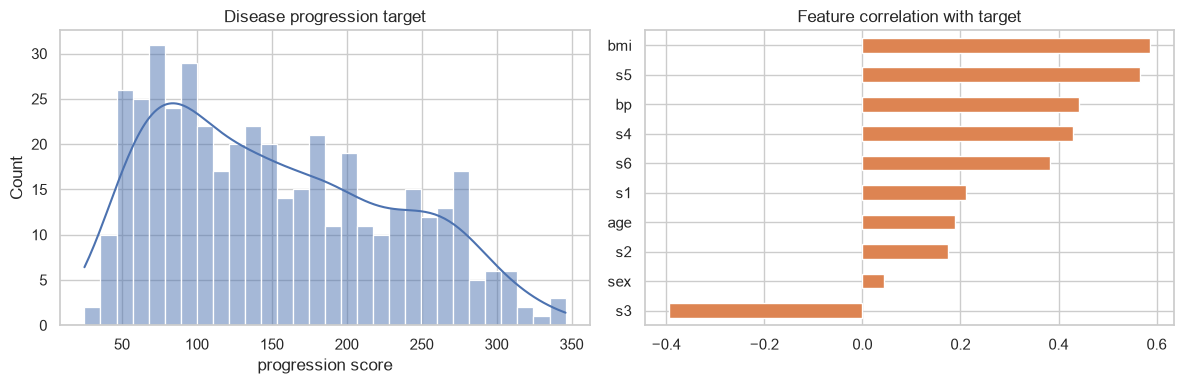

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y, bins=30, kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Disease progression target")
axes[0].set_xlabel("progression score")

corr = X.join(y.rename("target")).corr()["target"].drop("target").sort_values()
corr.plot(kind="barh", ax=axes[1], color="#dd8452")
axes[1].set_title("Feature correlation with target")
plt.tight_layout()
plt.show()

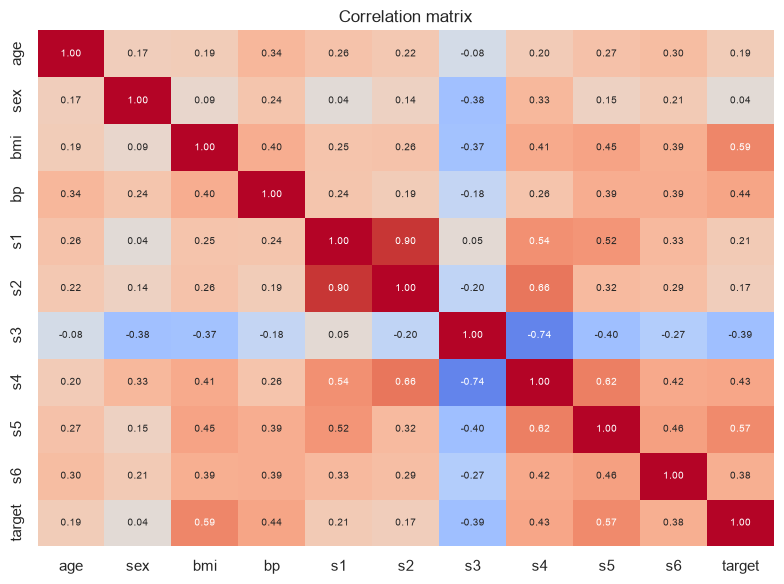

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(X.join(y.rename("target")).corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, cbar=False, annot_kws={"size": 7})
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

## 3. Train / test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"train: {X_train.shape[0]}   test: {X_test.shape[0]}")

train: 353   test: 89


## 4. Baseline model — Linear Regression

`StandardScaler` + `LinearRegression` wrapped in a single `Pipeline`, so the app only has to hand over raw
feature values.

In [7]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
baseline.fit(X_train, y_train)

def evaluate(pipe, name):
    pred = pipe.predict(X_test)
    scores = {
        "model": name,
        "r2": r2_score(y_test, pred),
        "mae": mean_absolute_error(y_test, pred),
        "rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
        "cv_r2": cross_val_score(pipe, X, y, cv=5, scoring="r2").mean(),
    }
    return scores

base_scores = evaluate(baseline, "LinearRegression")
base_scores

{'model': 'LinearRegression',
 'r2': 0.45260276297191937,
 'mae': 42.79409467959994,
 'rmse': 53.85344583676593,
 'cv_r2': np.float64(0.48231643590864215)}

### Compare against regularised variants (sanity check that the baseline is a fair pick)

In [8]:
candidates = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=1.0)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso(alpha=0.1)": Lasso(alpha=0.1, random_state=RANDOM_STATE),
}

rows = []
for name, est in candidates.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", est)])
    pipe.fit(X_train, y_train)
    rows.append(evaluate(pipe, name))

pd.DataFrame(rows).set_index("model").round(4)

,r2,mae,rmse,cv_r2
model,,,,
LinearRegression,0.4526,42.7941,53.8534,0.4823
Ridge(alpha=1.0),0.4541,42.8120,53.7775,0.4822
Lasso(alpha=0.1),0.4555,42.8052,53.7087,0.4825


The three are within noise of each other — the plain **Linear Regression** baseline is what we ship,
as requested.

## 5. Diagnostics

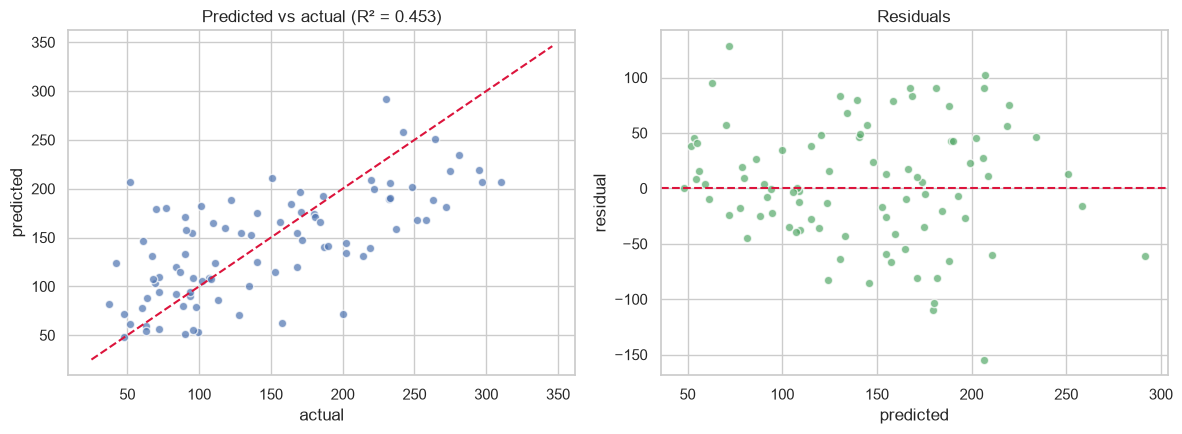

In [9]:
y_pred = baseline.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test, y_pred, alpha=0.7, color="#4c72b0", edgecolor="white")
lims = [y.min(), y.max()]
axes[0].plot(lims, lims, "--", color="crimson")
axes[0].set_xlabel("actual"); axes[0].set_ylabel("predicted")
axes[0].set_title(f"Predicted vs actual (R² = {r2_score(y_test, y_pred):.3f})")

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.7, color="#55a868", edgecolor="white")
axes[1].axhline(0, ls="--", color="crimson")
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("residual")
axes[1].set_title("Residuals")
plt.tight_layout()
plt.show()

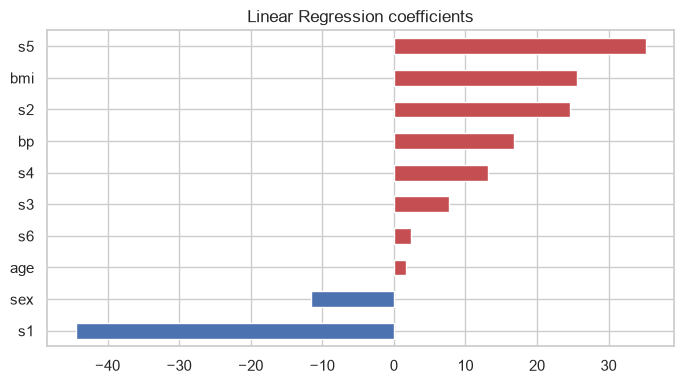

s1    -44.45
sex   -11.51
age     1.75
s6      2.35
s3      7.68
s4     13.14
bp     16.83
s2     24.64
bmi    25.61
s5     35.16
Name: coefficient (on standardised features), dtype: float64

In [10]:
coeffs = pd.Series(
    baseline.named_steps["model"].coef_,
    index=X.columns,
    name="coefficient (on standardised features)",
).sort_values()

plt.figure(figsize=(7, 4))
coeffs.plot(kind="barh", color=np.where(coeffs > 0, "#c44e52", "#4c72b0"))
plt.title("Linear Regression coefficients")
plt.tight_layout()
plt.show()
coeffs.round(2)

## 6. From a score to a class label

The toy dataset has no ready-made diabetic / non-diabetic flag, so we derive one from the progression score.
We use **140** as the cut-off (roughly the upper tertile of the target, and a value that splits the cohort into
a clearly-progressing group and the rest):

| band | score | label |
|---|---|---|
| Low | `< 100` | Not diabetic — low risk |
| Borderline | `100 – 139` | Not diabetic — borderline / pre-diabetic |
| High | `>= 140` | Diabetic — high progression risk |

This is a **teaching heuristic on a toy dataset, not a clinical cut-off.**

In [11]:
THRESHOLD = 140.0
BANDS = [
    {"name": "Low risk",   "max": 100.0, "diabetic": False},
    {"name": "Borderline", "max": 140.0, "diabetic": False},
    {"name": "High risk",  "max": None,  "diabetic": True},
]

y_test_cls = (y_test >= THRESHOLD).astype(int)
y_pred_cls = (y_pred >= THRESHOLD).astype(int)

print(f"classification accuracy at threshold {THRESHOLD:.0f}: "
      f"{accuracy_score(y_test_cls, y_pred_cls):.3f}\n")
print(classification_report(y_test_cls, y_pred_cls,
                            target_names=["Not diabetic", "Diabetic"]))

classification accuracy at threshold 140: 0.764

              precision    recall  f1-score   support

Not diabetic       0.81      0.72      0.76        47
    Diabetic       0.72      0.81      0.76        42

    accuracy                           0.76        89
   macro avg       0.77      0.77      0.76        89
weighted avg       0.77      0.76      0.76        89



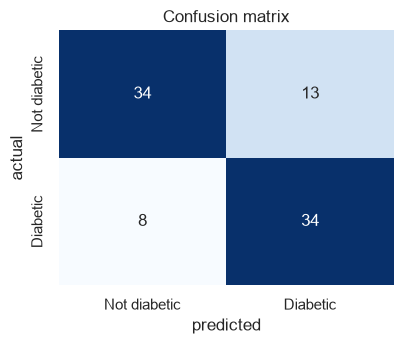

In [12]:
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not diabetic", "Diabetic"],
            yticklabels=["Not diabetic", "Diabetic"])
plt.xlabel("predicted"); plt.ylabel("actual"); plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

## 7. Save the model + metadata

`models/diabetes_model.joblib` holds the fitted pipeline. `models/model_metadata.json` carries everything the
Streamlit app needs to build its form (feature order, labels, sensible slider ranges) and to explain the
result (threshold, bands, metrics).

In [13]:
model_path = MODEL_DIR / "diabetes_model.joblib"
meta_path = MODEL_DIR / "model_metadata.json"

# refit on the full dataset for the shipped artefact
final_model = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
final_model.fit(X, y)
joblib.dump(final_model, model_path)

metadata = {
    "model_type": "Pipeline(StandardScaler, LinearRegression)",
    "dataset": "sklearn.datasets.load_diabetes(scaled=False)",
    "target": "Quantitative measure of diabetes progression one year after baseline",
    "trained_on_samples": int(X.shape[0]),
    "threshold": THRESHOLD,
    "bands": BANDS,
    "target_min": float(y.min()),
    "target_max": float(y.max()),
    "target_mean": float(y.mean()),
    "metrics": {k: (round(v, 4) if isinstance(v, float) else v) for k, v in base_scores.items()},
    "classification_accuracy": round(float(accuracy_score(y_test_cls, y_pred_cls)), 4),
    "features": [
        {
            "name": col,
            "label": FEATURE_LABELS[col],
            "min": float(X[col].min()),
            "max": float(X[col].max()),
            "mean": round(float(X[col].mean()), 2),
            "step": 1.0 if col in ("sex",) else 0.1,
            "coefficient": round(float(coeffs[col]), 4),
        }
        for col in X.columns
    ],
}
meta_path.write_text(json.dumps(metadata, indent=2))

print(f"saved -> {model_path}")
print(f"saved -> {meta_path}")

saved -> models/diabetes_model.joblib
saved -> models/model_metadata.json


## 8. Reload and smoke-test the saved artefacts

In [14]:
loaded = joblib.load(model_path)
meta = json.loads(meta_path.read_text())

sample = X.mean().to_frame().T            # an "average patient"
score = float(loaded.predict(sample)[0])

def classify(score, meta):
    for band in meta["bands"]:
        if band["max"] is None or score < band["max"]:
            return band
    return meta["bands"][-1]

band = classify(score, meta)
print(f"average-patient progression score : {score:.1f}")
print(f"band                              : {band['name']}")
print(f"diabetic                          : {band['diabetic']}")

average-patient progression score : 152.1
band                              : High risk
diabetic                          : True
